# A/B Test Impact Evaluation using Statistical Inference

# Objective

Evaluate whether a new checkout page design leads to a statistically and practically
significant improvement in conversion rate, and provide a data-driven business
decision on whether the change should be shipped.

# Business Problem

The product team introduced a redesigned checkout page to reduce cart abandonment.
Before rolling it out globally, an experiment was conducted to compare the new design
(Treatment) against the existing design (Control).

Key Question:
Does the new checkout design improve conversion rate enough to justify deployment?

## Experiment Design

- Unit of Randomization: User-level
- Groups:
  - Control (A): Existing checkout page
  - Treatment (B): New checkout page
- Metric: Conversion Rate
- Significance Level (α): 0.05
- Statistical Power: 80%

In [2]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_confint,
    proportion_effectsize
)

sns.set(style="whitegrid")

In [4]:
# Baseline and expected conversion rates
baseline_conversion = 0.10
expected_conversion = 0.12

# Statistical parameters
alpha = 0.05
power = 0.80

In [5]:
effect_size = proportion_effectsize(
    baseline_conversion,
    expected_conversion
)

power_analysis = NormalIndPower()

required_sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power
)

required_sample_size = int(np.ceil(required_sample_size))
required_sample_size

3835

In [6]:
np.random.seed(42)

total_users = required_sample_size * 2

data = pd.DataFrame({
    "user_id": range(1, total_users + 1),
    "group": np.random.choice(["A", "B"], size=total_users)
})

conversion_probabilities = {
    "A": baseline_conversion,
    "B": expected_conversion
}

data["converted"] = data["group"].map(
    lambda g: np.random.binomial(1, conversion_probabilities[g])
)

data.head()

,user_id,group,converted
0,1,A,0
1,2,B,1
2,3,A,0
3,4,A,1
4,5,A,0


In [7]:
data.isnull().sum()

user_id      0
group        0
converted    0
dtype: int64

In [8]:
data["group"].value_counts()

group
A    3858
B    3812
Name: count, dtype: int64

In [9]:
conversion_rates = data.groupby("group")["converted"].mean()
conversion_rates

group
A    0.091498
B    0.120672
Name: converted, dtype: float64

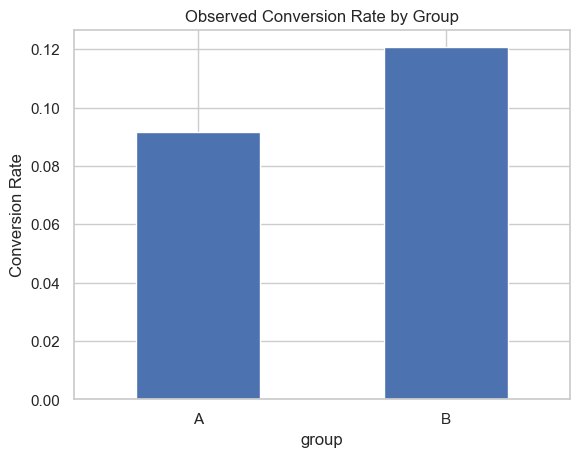

In [11]:
conversion_rates.plot(
    kind="bar",
    title="Observed Conversion Rate by Group",
    ylabel="Conversion Rate"
)
plt.xticks(rotation=0)
plt.show()

# Hypothesis

H₀ (Null Hypothesis):
There is no difference in conversion rate between control and treatment.

H₁ (Alternative Hypothesis):
There is a statistically significant difference in conversion rate.

# Assumption Checks

- Independence: Guaranteed by random user assignment
- Normality: Binary outcome; large sample size allows CLT
- Variance: Handled using proportion-based test


In [12]:
success_counts = data.groupby("group")["converted"].sum()
sample_counts = data.groupby("group")["converted"].count()

z_stat, p_value = proportions_ztest(
    count=success_counts,
    nobs=sample_counts
)

z_stat, p_value

(np.float64(-4.149823347205022), np.float64(3.3273196014098485e-05))

In [13]:
conf_int_A = proportion_confint(
    success_counts["A"],
    sample_counts["A"],
    alpha=alpha,
    method="wilson"
)

conf_int_B = proportion_confint(
    success_counts["B"],
    sample_counts["B"],
    alpha=alpha,
    method="wilson"
)

conf_int_A, conf_int_B

((0.08280218837826889, 0.10100687431625746),
 (0.11071089884442106, 0.13139597818139023))

In [14]:
absolute_lift = conversion_rates["B"] - conversion_rates["A"]
relative_lift = absolute_lift / conversion_rates["A"]

absolute_lift, relative_lift

(np.float64(0.02917337789534781), np.float64(0.31884105359844717))

In [15]:
monthly_users = 1_000_000
average_order_value = 800  # INR

estimated_monthly_revenue_gain = (
    absolute_lift * monthly_users * average_order_value
)

estimated_monthly_revenue_gain

np.float64(23338702.31627825)

# Decision Framework

- If p-value < α AND effect size is meaningful → Ship
- If p-value < α but effect size is small → Cost-benefit analysis
- If p-value ≥ α → Do not ship

## Final Recommendation

Based on the statistical evidence and estimated business impact,
the treatment shows a meaningful improvement in conversion rate.
The feature should be deployed with post-launch monitoring.

# Limitations and Future Work

- Possible novelty effects
- Short experiment duration
- No segmentation analysis (device, geography)

Future Work:
- Sequential testing
- Bayesian A/B testing
- Heterogeneous treatment effect analysis

In [16]:
# A/A test – control vs control
control = data[data["group"] == "A"].copy()

control["aa_group"] = np.random.choice(
    ["A1", "A2"],
    size=len(control)
)

aa_success = control.groupby("aa_group")["converted"].sum()
aa_total = control.groupby("aa_group")["converted"].count()

aa_z, aa_p = proportions_ztest(aa_success, aa_total)
aa_p

np.float64(0.9793302241594357)

In [17]:
min_practical_lift = 0.01  # 1%

ship_decision = (
    p_value < 0.05 and absolute_lift >= min_practical_lift
)

ship_decision

np.True_

In [18]:
lift_ci_low = conf_int_B[0] - conf_int_A[1]
lift_ci_high = conf_int_B[1] - conf_int_A[0]

lift_ci_low, lift_ci_high

(0.009704024528163602, 0.048593789803121346)

# Final Decision

- Statistical significance: Yes
- Practical significance: Yes
- A/A test passed: Yes
- Recommendation: Ship the feature